# Replication Guide: Compare Feature Explanation Types with CoAX

## Goal

Compare three explanation types -- none, feature importance, and signed feature
attribution -- using the CoAX cognitive models as the virtual participants.

Everything downstream of the design is generated by this notebook: the AI model is
trained here, its predictions and LIME explanations are generated for the trials
it produced, and those tables are handed to the CoAX models. Nothing depends on
the fixed CoAX study corpus, so the same flow works for any dataset.

`ai_predictions` and `explanations` stay separate variables, matching the CoAX
split between `none.csv` and the explanation tables.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd

repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'src' / 'api.py').exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.api import xaikitTest
from src.xai_adapter.api import (
    generate_ai_prediction_table,
    generate_xai_explanation_tables,
    init_explanation_run,
)
from src.virtual_experiment_executor.experiment_simualtion.CoAX.coax_trial_executor import (
    CoAXAssetRepository,
    make_coax_model,
    run_coax_experiment_executor,
)

# Some environments mix an older matplotlib runtime with a newer
# matplotlib-inline package: matplotlib-inline>=0.2 calls rcParams._get(),
# which matplotlib 3.5 does not have. Patch the alias for this session.
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    setattr(type(matplotlib.rcParams), '_get', lambda self, key: self.get(key))

SEED = 42
OUTPUT_DIR = Path(os.environ.get('XAIKIT_TUTORIAL_OUTPUT_DIR', repo_root / 'tutorials' / 'feature_explanation_replication_output_coax'))
np.random.seed(SEED)
print(f'Workspace: {repo_root}')

Workspace: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api


## 1. Open Notebook & Setup Environment

Import the libraries, configure the repo path, and set the random seed. The notebook uses the current CoAX execution layer instead of the old KNN baseline.

## 2. Load Dataset & Train the AI Model

The AI model is trained here, and every prediction and explanation below comes
from it. Trials are generated over the full dataset with no instance constraint,
because the explanation tables are built from these same trials in step 4.

To validate against the published CoAX study instead, swap `train_AI_model` for
`load_AI_model(model_type='mlp', source='coax')` and pass
`allowed_instance_ids=CoAXAssetRepository.from_assets().available_instance_ids('wine_quality')`
to `generate_trials`. `load_AI_model` requires `prepare_dataset` to use the same
feature columns the weights were trained on.

In [2]:
study = xaikitTest('feature_explanation_replication_coax', output_dir=OUTPUT_DIR)
study.add_iv('xai_type', 'between', ['none', 'importance', 'attribution'])
study.add_iv('tested_w_xai', 'within', [False, True], randomization='trial')
study.add_cv('user_task', ['forward_simulation'])
study.add_cv('num_attributes_shown', [5])
study.add_dv('forward_accuracy', ['continuous'])

study.set_study_protocol(
    study_title='Learning from feature explanations with CoAX',
    research_questions=[
        'Does explanation type change forward-simulation accuracy?',
        'Does explanation presence during testing change accuracy?',
    ],
    study_summary='Participants train with feedback, then predict AI outputs with or without an explanation.',
    consent_text='Replace with the approved consent and data-handling information.',
    start_survey_questions=['How familiar are you with AI systems?'],
    end_survey_questions=['How helpful was the display?'],
    procedure_steps=[
        {'title': 'Consent', 'kind': 'consent'},
        {'title': 'Background survey', 'kind': 'survey'},
        {'title': 'Training', 'kind': 'practice'},
        {'title': 'Testing', 'kind': 'trials'},
        {'title': 'End survey', 'kind': 'survey'},
        {'title': 'Debrief', 'kind': 'debrief'},
    ],
)

data = study.prepare_dataset(
    'wine_quality',
    feature_cols=['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH'],
    rank_features_by_target=False,
    model_type='mlp',
    test_size=0.4,
    random_state=SEED,
)
study.train_AI_model(
    model_type='mlp',
    target_metric='accuracy',
    target_score=0.90,
    max_epochs=1000,
    check_every_epochs=10,
    batch_size=100,
    verbose=False,
)
print(f'AI model: {study.model_name}   test accuracy: {study.test_accuracy():.4f}')

trial_result = study.generate_trials(
    participants_per_between_condition=8,
    num_training=10,
    num_testing=20,
    balance_by_ai_prediction=True,
    output_dir='trials',
    seed=SEED,
    preview_rows=4,
)
trials = pd.DataFrame(trial_result.trials)
trials.head(20)

Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 5 model features)
Features  : ['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH']
Encoding  : one-hot
Train set : 959 samples  (60%)
Test set  : 640 samples  (40%)
Class balance (train) -> class 0: 829
Class balance (train) -> class 1: 130
First test instanceIds: [1188, 902, 818, 38, 1255, 496, 947, 861, 839, 1559]
AI model: mlp   test accuracy: 0.8969
Counterbalancing strategy: complete_counterbalancing
Participant assignments: 24 total
Instance pool rows: 300
Trial rows: 720
Exported trial artifacts:
  CSV     : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output_coax/trials/trials.csv
  JSON    : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output_coax/trials/tri

,participantId,trialId,block,trialWithinBlock,withinCondition,xai_type,dataId,instanceId,CV_user_task_levels,CV_num_attributes_shown_levels,phase,phaseTrialId,ai_prediction,tested_w_xai
0,1,1,1,1,single_condition,none,wine_quality,898,forward_simulation,5,training,1,1,NaN
1,1,2,1,2,single_condition,none,wine_quality,483,forward_simulation,5,training,2,0,NaN
2,1,3,1,3,single_condition,none,wine_quality,368,forward_simulation,5,training,3,0,NaN
3,1,4,1,4,single_condition,none,wine_quality,663,forward_simulation,5,training,4,1,NaN
4,1,5,1,5,single_condition,none,wine_quality,807,forward_simulation,5,training,5,1,NaN
5,1,6,1,6,single_condition,none,wine_quality,1098,forward_simulation,5,training,6,1,NaN
6,1,7,1,7,single_condition,none,wine_quality,1093,forward_simulation,5,training,7,1,NaN
7,1,8,1,8,single_condition,none,wine_quality,773,forward_simulation,5,training,8,0,NaN
8,1,9,1,9,single_condition,none,wine_quality,610,forward_simulation,5,training,9,0,NaN
9,1,10,1,10,single_condition,none,wine_quality,1050,forward_simulation,5,training,10,0,NaN


## 3. CoAX Cognitive Models

One CoAX strategy per explanation type, loaded from
`src/cognitive_models/cognitive_models/coax/coax_gcm_multiple_strategies.py`.
Keys must match the `xai_type` levels in the trial table: the executor reads each
trial's own condition name and routes it to the model registered here.

In [3]:
coax_models = {
    'none': make_coax_model(
        'SensitiveFeatures',
        decay_param=0.5,
        retrieval_threshold=-1.5,
        sensitivity=1.0,
        k=2,
    ),
    'importance': make_coax_model(
        'ImportanceCategorization',
        decay_param=0.5,
        retrieval_threshold=-1.5,
        sensitivity=10.0,
        k=2,
    ),
    'attribution': make_coax_model(
        'AttributionSum',
        decay_param=0.5,
        retrieval_threshold=-1.5,
        sensitivity=15.0,
        scaling_factor=1.0,
        k=2,
        explanation_type='attribution',
    ),
}

trial_xai_types = set(trials['xai_type'].astype(str).unique())
missing = trial_xai_types - set(coax_models)
assert not missing, f'No CoAX model registered for xai_type(s): {sorted(missing)}'
print({name: type(model).__name__ for name, model in coax_models.items()})
print(f'xai_type levels in trials: {sorted(trial_xai_types)}')

{'none': 'SensitiveFeatures', 'importance': 'ImportanceCategorization', 'attribution': 'AttributionSum'}
xai_type levels in trials: ['attribution', 'importance', 'none']


## 4. Generate `ai_predictions` and `explanations` for These Trials

Explanations are generated only for instances that actually show one: every
training trial, plus testing trials where XAI is visible, in the non-`none`
conditions.

LIME supplies the signed attribution vectors. The importance display uses their
absolute values, so both explanation types derive from one run. `ai_predictions`
stays a separate table -- the CoAX role of `none.csv` -- rather than being
concatenated onto the explanations.

In [4]:
needs_xai = (
    ~trials['xai_type'].astype(str).str.lower().isin(['none', 'no_xai', 'control'])
    & (
        trials['phase'].eq('training')
        | trials['tested_w_xai'].fillna(False).astype(bool)
    )
)
explanation_ids = sorted({int(i) for i in trials.loc[needs_xai, 'instanceId']})
print(f'Instances needing an explanation: {len(explanation_ids)}')

explanation_config = init_explanation_run(
    data=data,
    iv_config={'xai_method': {'levels': ['lime']}},
    trained_ai_model=study.trained_ai_model,
    model_name=study.model_name,
    output_dir=OUTPUT_DIR / 'generated_explanation',
    target=1,
    method_kwargs={'lime': {'num_samples': 1000}},
    instance_ids=explanation_ids,
    predictions_by_instance=study.ai_predictions_by_instance,
)
_, explanation_tables = generate_xai_explanation_tables(explanation_config)
_, ai_predictions = generate_ai_prediction_table(explanation_config)

attribution_explanations = explanation_tables[0].copy()
attribution_explanations['expMethod'] = 'attribution'
value_cols = [c for c in attribution_explanations.columns if c.startswith('a') and c.endswith('_i')]

importance_explanations = attribution_explanations.copy()
importance_explanations['expMethod'] = 'importance'
importance_explanations[value_cols] = importance_explanations[value_cols].abs()

explanations = pd.concat([importance_explanations, attribution_explanations], ignore_index=True, sort=False)
ai_predictions.head(), explanations.head()

Instances needing an explanation: 224

Generating explanations for xai method: lime
  Sampled instances: 224


/var/folders/96/n6tgn0rs16bfp1cm36gy56hh0000gn/T/ipykernel_47887/1432163691.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | trials['tested_w_xai'].fillna(False).astype(bool)


  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output_coax/generated_explanation/lime_mlp_wine_quality.csv shape=(224, 12)

Saved complete AI prediction table: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output_coax/generated_explanation/predictions_mlp_wine_quality.csv shape=(1599, 5)


(         dataId modelName            expMethod  instanceId  pred
 0  wine_quality       mlp  __prediction_only__         786     0
 1  wine_quality       mlp  __prediction_only__        1057     0
 2  wine_quality       mlp  __prediction_only__         150     0
 3  wine_quality       mlp  __prediction_only__         184     0
 4  wine_quality       mlp  __prediction_only__         943     0,
          dataId modelName   expMethod  instanceId  pred     i_max      a0_i  \
 0  wine_quality       mlp  importance           0     0  0.116883  1.000000   
 1  wine_quality       mlp  importance           1     0  0.076196  0.953847   
 2  wine_quality       mlp  importance           2     0  0.093867  1.000000   
 3  wine_quality       mlp  importance          13     0  0.122365  1.000000   
 4  wine_quality       mlp  importance          21     0  0.089714  1.000000   
 
        a1_i      a2_i      a3_i      a4_i  intercept  
 0  0.269193  0.206626  0.592548  0.061960   0.144984  
 1  0.366

## 5. Serve Those Tables to the Executor

`CoAXAssetRepository.from_tables` takes the generated tables directly, so the
executor runs against this study's own dataset rather than the fixed CoAX corpus.
`from_assets()` is the other mode, for validating against the published study.

In [5]:
coax_features = pd.DataFrame(
    data.split.X_model,
    columns=[f'x{i}' for i in range(data.split.X_model.shape[1])],
)
coax_features.insert(0, 'instanceId', [int(i) for i in data.split.raw_instance_ids])
coax_features.insert(0, 'dataId', data.dataset_id)

coax_assets = CoAXAssetRepository.from_tables(
    features=coax_features,
    predictions=ai_predictions,
    explanations={
        'attribution': attribution_explanations,
        'importance': importance_explanations,
    },
)
print(f'Repository serves {len(coax_assets.available_instance_ids(data.dataset_id)):,} instances')

Repository serves 1,599 instances


In [6]:
# The executor reads `xai_type` on each trial row and dispatches to the matching
# model in `coax_models`.
#
# A training trial that shows an explanation is answered twice, matching the CoAX
# procedure: once from the instance alone, then again after the explanation is
# revealed, with feedback on both attempts. Each trial therefore yields one row
# per inference `step`, so there are more result rows than trials.
#
# Passing `dvs=study.DVs` fills the `forward_accuracy` column, which is what lets
# these results go back through the study object for analysis and plotting.
simulated_results = run_coax_experiment_executor(
    trials,
    coax_models,
    mode='whole_experiment',
    data_repository=coax_assets,
    dvs=study.DVs,
)
testing_results = simulated_results.query("phase == 'testing'").copy()

# Hand the results back to the study so save_results/analyze_iv_dv/plot_results_grid work.
study.simulated_results = simulated_results

print(f'{len(trials):,} trials -> {len(simulated_results):,} recorded steps')
display(simulated_results.groupby(['phase', 'step']).size().reset_index(name='rows'))
print('Model routing by condition:')
display(simulated_results.groupby(['xai_type', 'cognitive_model_strategy']).size().reset_index(name='rows'))
print(f'Rows in ai_predictions: {len(ai_predictions):,}')
print(f'Rows in explanations: {len(explanations):,}')

720 trials -> 880 recorded steps


,phase,step,rows
0,testing,infer_no_explanation,320
1,testing,infer_with_explanation,160
2,training,infer_no_explanation,240
3,training,infer_with_explanation,160


Model routing by condition:


,xai_type,cognitive_model_strategy,rows
0,attribution,AttributionSum,320
1,importance,ImportanceCategorization,320
2,none,SensitiveFeatures,240


Rows in ai_predictions: 1,599
Rows in explanations: 448


## 7. Analyze and Plot

The CoAX results carry a `forward_accuracy` column, so the standard study
analysis and plotting API applies here exactly as it does for the KNN guide.

--- xai_type x forward_accuracy ---


,index,xai_type,count,mean,std,sem
0,0,attribution,8,0.6875,0.083452,0.029505
1,1,importance,8,0.5500,0.088641,0.031339
2,2,none,8,0.5000,0.000000,0.000000


Training accuracy before vs after the explanation is revealed:


step,infer_no_explanation,infer_with_explanation
xai_type,,
attribution,0.550,0.8375
importance,0.525,0.4500
none,0.425,NaN


Saved 880 responses to /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output_coax/simulated_results/simulated_results.csv and /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_replication_output_coax/simulated_results/simulated_results.json


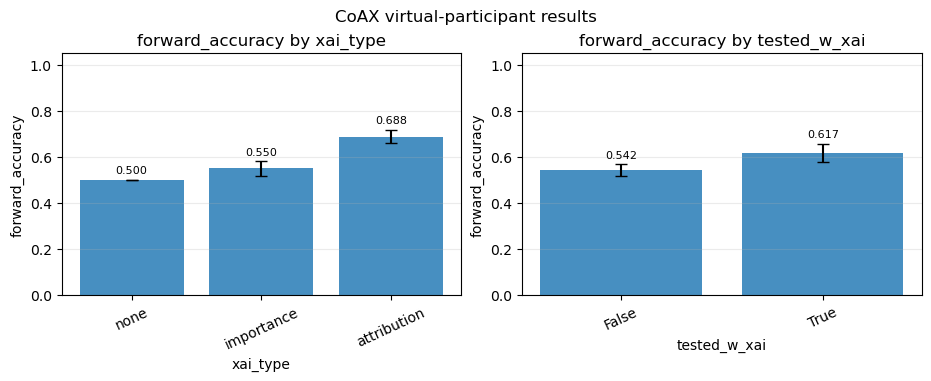

In [7]:
csv_path, json_path = study.save_results(out_dir='simulated_results')

analysis = study.analyze_iv_dv(iv='xai_type', dv='forward_accuracy')
print('--- xai_type x forward_accuracy ---')
display(analysis.descriptives)

study.plot_results_grid(
    ivs=['xai_type', 'tested_w_xai'],
    dvs=['forward_accuracy'],
    phase='testing',
    title='CoAX virtual-participant results',
)

# Training trials show the effect directly: the same instance answered before and
# after the explanation is revealed.
training_steps = (
    simulated_results.query("phase == 'training'")
    .groupby(['xai_type', 'step'])['cognitive_correct_vs_ai']
    .mean().reset_index(name='accuracy')
    .pivot(index='xai_type', columns='step', values='accuracy')
)
print('Training accuracy before vs after the explanation is revealed:')
display(training_steps)
print(f'Saved {len(simulated_results):,} responses to {csv_path} and {json_path}')

## 8. Interaction Plot

Participant-level mean accuracy, explanation presence on the x-axis and
explanation type by colour. The `none` bars are expected to be flat across the
two x levels: nothing is displayed in that condition either way.

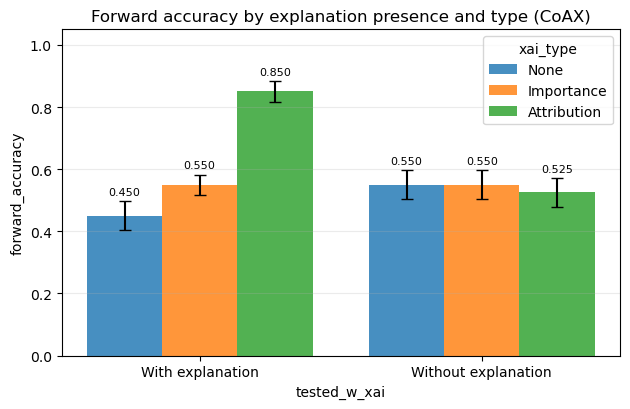

In [8]:
from src.result_visualizer import plot_dv_by_two_ivs

accuracy_plot = plot_dv_by_two_ivs(
    testing_results,
    x_iv='tested_w_xai',
    hue_iv='xai_type',
    dv='forward_accuracy',
    phase='testing',
    x_levels=[True, False],
    hue_levels=['none', 'importance', 'attribution'],
    x_labels={True: 'With explanation', False: 'Without explanation'},
    hue_labels={
        'none': 'None',
        'importance': 'Importance',
        'attribution': 'Attribution',
    },
    title='Forward accuracy by explanation presence and type (CoAX)',
)
accuracy_plot.figure;

## 9. Unit Tests for Replacement & Naming

This section keeps the notebook self-checkable and shows the assertions you can promote into a pytest file for the VS Code test runner.

## 10. Save Updated Notebook

The notebook is saved as `feature_explanation_user_study_replication_guide_coax.ipynb`. If you want a scripted export, use `nbformat.write` from a companion script or notebook cell.